# Topology And Hubs

This notebook quantifies GCC topology and identifies high-degree hub genes in the RNA and protein GCC networks.

## Inputs




- `RNA_CSD_GCC.txt` and `Protein_CSD_GCC.txt` from `network_and_gcc`


- GCC edge tables that can be reloaded into NetworkX graphs for degree-based summaries




## Outputs




- Degree-distribution figures


- Node-degree export tables


- A combined GCC hub summary table for downstream interpretation




## Pipeline




1. Load the RNA and protein GCC edge tables and rebuild the corresponding graphs.


2. Summarize the degree distributions for both GCC networks.


3. Export reusable node-degree tables.


4. Build one shared hub summary table with degree and homogeneity annotations.




## Setup




The first code cell reloads notebook-specific helpers from `Pipeline/4_Network_Analysis/utils/topology_and_hubs.py`, uses shared context helpers from `Pipeline/4_Network_Analysis/utils/network_and_gcc.py`, resolves the GCC outputs from `network_and_gcc`, and initializes the graph objects reused in the later steps.

In [ ]:
import importlib

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

import utils as notebook_utils

notebook_utils = importlib.reload(notebook_utils)

from utils import (
    analyze_hub_homogeneity,
    build_analysis_context,
    ensure_gcc_output,
    find_top_hubs,
    load_edges_clean,
    load_graph,
    mark_hubs_in_cytoscape,
    plot_degree_distribution,
 )

ctx = build_analysis_context(notebook_name='topology_and_hubs', run_cytoscape=True, run_enrichment=False, save_figures=True)
rna_gcc_path = ensure_gcc_output(
    ctx.network_files['rna_csd'],
    ctx.notebook_output_path('network_and_gcc', 'RNA_CSD_GCC.txt'),
)
prot_gcc_path = ensure_gcc_output(
    ctx.network_files['prot_csd'],
    ctx.notebook_output_path('network_and_gcc', 'Protein_CSD_GCC.txt'),
)

gcc_rna = load_edges_clean(pd.read_csv(rna_gcc_path, sep='\t'))
gcc_prot = load_edges_clean(pd.read_csv(prot_gcc_path, sep='\t'))
G_rna_gcc = load_graph(gcc_rna)
G_prot_gcc = load_graph(gcc_prot)


Using cached GCC export: C:\Users\tiril\Master-Tiril\results\notebooks\01_network_and_gcc\RNA_CSD_GCC.txt
Using cached GCC export: C:\Users\tiril\Master-Tiril\results\notebooks\01_network_and_gcc\Protein_CSD_GCC.txt


## Step 1: Degree distributions

This step loads or regenerates the GCC files, builds NetworkX graphs with `load_graph`, and visualizes the degree distributions for the RNA and protein GCC networks.

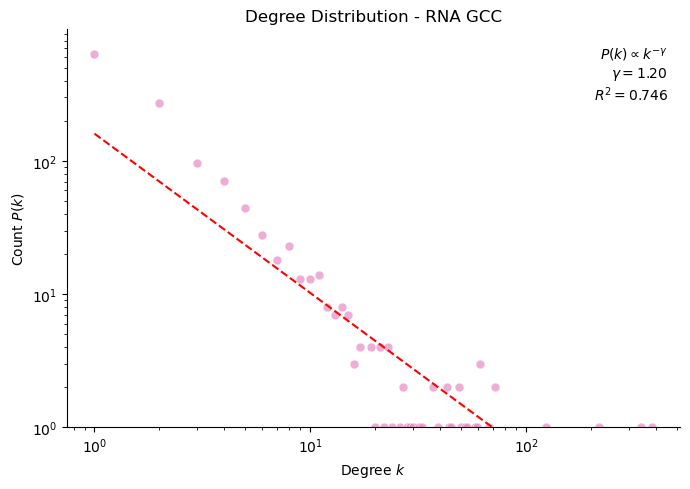

Power-law exponent gamma = 1.197, R^2 = 0.746


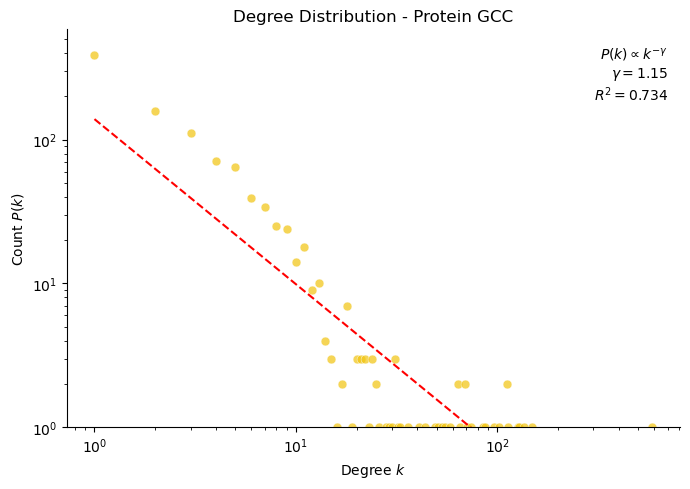

Power-law exponent gamma = 1.148, R^2 = 0.734


In [2]:
rna_degree = plot_degree_distribution(
    G_rna_gcc,
    'RNA GCC',
    color='#E78AC3',
)
prot_degree = plot_degree_distribution(
    G_prot_gcc,
    'Protein GCC',
    color='#F1C40F',
)

degree_distributions = {
    'RNA_CSD_GCC': rna_degree,
    'Protein_CSD_GCC': prot_degree,
}

## Step 2: Node degree export

This step builds full node-degree tables for all nodes in each GCC graph and saves them as reusable CSV files.

In [ ]:
rna_node_degrees = build_node_degree_table(G_rna_gcc)
prot_node_degrees = build_node_degree_table(G_prot_gcc)

rna_node_degrees.to_csv(ctx.output_path('RNA_GCC_node_degrees.csv'), index=False)
prot_node_degrees.to_csv(ctx.output_path('Protein_GCC_node_degrees.csv'), index=False)

,Node,Degree
0,SEPT7,383
1,RIF1,339
2,MATR3,217
3,ANKRD54,124
4,CUL4B,72
5,RECQL,72
6,CREB1,67
7,CBX3,61
8,PACSIN2,61
9,RBPJL,61


,Node,Degree
0,GSN,587
1,CANX,149
2,RRBP1,135
3,DPYSL3,128
4,PALLD,126
5,LUM,113
6,EHBP1L1,112
7,NOMO2,112
8,PDIA4,102
9,SND1,96


## Step 3: Hub summary export

This step writes one hub table with degree, edge-type counts, homogeneity score, and dominant edge type.

In [22]:
HUB_MIN_DEGREE = 50
HUB_OUTPUT_FILE = 'GCC_hubs.csv'


def build_hub_summary(gcc_df, modality, min_degree=HUB_MIN_DEGREE):
    hubs = find_top_hubs(gcc_df, min_degree=min_degree)
    degree_df = pd.DataFrame(hubs, columns=['Hub', 'Degree'])
    columns = [
        'Modality',
        'Hub',
        'Degree',
        'C_edges',
        'S_edges',
        'D_edges',
        'homogeneity_score',
        'dominant_type',
    ]

    if degree_df.empty:
        return pd.DataFrame(columns=columns)

    homogeneity_df = pd.DataFrame(analyze_hub_homogeneity(gcc_df, hubs))
    summary_df = degree_df.merge(homogeneity_df, on='Hub', how='left')
    summary_df = summary_df.rename(
        columns={
            'C_count': 'C_edges',
            'S_count': 'S_edges',
            'D_count': 'D_edges',
        }
    )
    summary_df.insert(0, 'Modality', modality)
    return summary_df[columns]


hub_summary_df = pd.concat(
    [
        build_hub_summary(gcc_rna, 'RNA'),
        build_hub_summary(gcc_prot, 'Protein'),
    ],
    ignore_index=True,
)

hub_summary_df.to_csv(ctx.output_path(HUB_OUTPUT_FILE), index=False, lineterminator='\n')
display(hub_summary_df)
print(f'Saved hub summary to {ctx.output_path(HUB_OUTPUT_FILE)}')


,Modality,Hub,Degree,C_edges,S_edges,D_edges,homogeneity_score,dominant_type
0,RNA,SEPT7,383,34,0,349,0.9112,D
1,RNA,RIF1,339,278,0,61,0.8201,C
2,RNA,MATR3,217,187,0,30,0.8618,C
3,RNA,ANKRD54,124,0,124,0,1.0000,S
4,RNA,RECQL,72,52,0,20,0.7222,C
5,RNA,CUL4B,72,61,0,11,0.8472,C
6,RNA,CREB1,67,61,0,6,0.9104,C
7,RNA,PACSIN2,61,0,61,0,1.0000,S
8,RNA,CBX3,61,5,0,56,0.9180,D
9,RNA,RBPJL,61,0,61,0,1.0000,S


Saved hub summary to C:\Users\tiril\Master-Tiril\results\notebooks\02_topology_and_hubs\GCC_hubs.csv
